In [1]:
## IMPORTS



import pandas as pd
import numpy as np
import h5py
import glob
import scipy
from scipy import optimize
from scipy.optimize import curve_fit


######### gabe hacky styling to emulate some of PBoC Phillips lab style conventions, however hacky. tries to make easier for nigel++
## Styling
import matplotlib
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("poster")
import matplotlib.colors as mcolors
import matplotlib.cm as cm
# sns.set_style('ticks')

import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Set the property to save figures with text as text, not paths
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# default good PBoC colors
baseBlendColor=(224/255, 219/255, 209/255,1) # default background for plots
contrastColor=(209/255, 193/255, 171/255,1) # slightly darker tan for contrasts, e.g. in inset boxes
yellowTanHighlightBoxColor='#FEF0C6'
goodGreyGreenArrowColor='#CCD4C9'


### Griffin style invocation

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.path import Path
from matplotlib.patches import BoxStyle
from matplotlib.offsetbox import AnchoredText

def plotting_style(grid=False):
    """
    Sets the style to the publication style. To instantiate, simply call
    plotting_style() at the beginning of your script or notebook to force
    all matplotlib plots to adopt the scheme.

    Parameters
    ----------
    grid: bool
      If True, plots will have a thin, white grid in the background. Default
      is False.

    Returns
    -------
    colors: dict
      Returns a dictionary of the standard PBoC 2e color palette.
    """
    rc = {'axes.facecolor': '#E3DCD0',
#               'axes.spines.top': False,
#               'axes.spines.right': False,
#               'axes.spines.left': False,  # Ensure left spine is present
#               'axes.spines.bottom': False,  # Ensure bottom spine is present
#               'axes.spines.left': False, #{'color': '#E3DCD0', 'linewidth': 1.5},  # Set the spine color to the background color
#               'axes.spines.bottom': False, #{'color': '#E3DCD0', 'linewidth': 1.5},  # Set the spine color to the background color
          #'font.family': '/usr/share/fonts/truetype/LucidaSansOT.otf', #'LucidaSansOT.otf',
          'grid.linestyle': '-',
          'grid.linewidth': 0.5,
          'grid.alpha': 0.75,
          'grid.color': '#ffffff',
          'axes.grid': grid,
          'ytick.direction': 'in',
          'xtick.direction': 'in',
          'xtick.gridOn': grid,
          'ytick.gridOn': grid,
#               'ytick.major.width':8,
#               'xtick.major.width':8,
#               'ytick.major.size': 8,
#               'xtick.major.size': 8,
          'mathtext.fontset': 'stixsans',
          'mathtext.sf': 'sans',
          'legend.frameon': True,
          'legend.facecolor': '#FFEDCE',
          'figure.dpi': 150,
          'xtick.color': 'k',
          'ytick.color': 'k'
         }
    plt.rc('text.latex', preamble=r'\usepackage{sfmath}')
    plt.rc('mathtext', fontset='stixsans', sf='sans')
    sns.set_style('darkgrid', rc=rc)
    return color_palette()

def color_palette():
    """
    Returns a dictionary of the PBOC color palette
    """
    return {'green': '#7AA974', 'light_green': '#BFD598',
              'pale_green': '#DCECCB', 'yellow': '#EAC264',
              'light_yellow': '#F3DAA9', 'pale_yellow': '#FFEDCE',
              'blue': '#738FC1', 'light_blue': '#A9BFE3',
              'pale_blue': '#C9D7EE', 'red': '#D56C55', 'light_red': '#E8B19D',
              'pale_red': '#F1D4C9', 'purple': '#AB85AC',
              'light_purple': '#D4C2D9', 'dark_green':'#7E9D90', 'dark_brown':'#905426'}

def titlebox(
    ax, text, color, bgcolor=None, size=8, boxsize=0.1, pad=0.05, **kwargs
):
    """
    Sets a colored title box above the plot, spanning the entire plot width.

    Parameters
    ----------
    ax : matplotlib axis object
      The axis on which you want to add the titlebox.
    text: str
      The title tect
    bgcolor: str or None
      The background color of the title box. Default is no color (blank).
    size:  int
      Size of the text font
    boxsize: float [0, 1]
      Fraction of the total plot height to be occupied by the box. Default is 10% (0.1).
    pad: float
      The padding space between the title box and the top of the plot.

    """
    boxsize=str(boxsize * 100)  + '%'
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("top", size=boxsize, pad=pad)
    cax.get_xaxis().set_visible(False)
    cax.get_yaxis().set_visible(False)
    cax.spines["top"].set_visible(False)
    cax.spines["right"].set_visible(False)
#     cax.spines["bottom"].set_visible(False)
#     cax.spines["left"].set_visible(False)

#     cax.spines["bottom"].set_visible(True)
#     cax.spines["left"].set_visible(True)
#     cax.spines["left"].set_color("white")
#     cax.spines["bottom"].set_color("white")
#     cax.spines["bottom"].set_color("white")

#     cax.set_ticks_position('both')  # Adding ticks to both top and bottom
#     cax.yaxis.set_tick_params(direction='in', which='both', color='white')  # The bottom will maintain the default of 'out'


    plt.setp(cax.spines.values(), color=color)
    if bgcolor != None:
        cax.set_facecolor(bgcolor)
    else:
        cax.set_facecolor("white")
    at = AnchoredText(text, loc=10, frameon=False, prop=dict(size=size, color=color))
    cax.add_artist(at)


### Now actually call it
plotting_style()

import matplotlib.patheffects as pe
matplotlib.rcParams['axes.autolimit_mode'] = 'data'

In [2]:
def ATP_conc_to_ratio(array, Km, Rmax, Rmin, nhill):
    """Given a set of concentrations, returns ratio values based on provided Hill equation coefficients"""
    return (Rmax-Rmin)*((array/Km)**nhill/(1 + (array/Km))**nhill) + Rmin

def ATP_ratio_to_conc(array, Km, Rmax, Rmin, nhill):
    """Given a set of ratios, returns concentration values based on provided Hill equation coefficients"""
    return Km * ((Rmin - array) / (array - Rmax)) ** (1/nhill)

In [3]:
#Langmuir equation
def Hill(conc, a, b, c):
    """
    Given a concentration value, this function returns an intensity value based on the Hill function given
    in Immamura et. al (ATeam paper)
    Parameters
    conc = 1D array of concentrations
    a, b, c, d parameters of the function
    
    Returns
    A 1D array of intensities corresponding to the given concentrations
    """
    
    
    
    return (((b-c)*(conc/a)/(1+(conc/a)))+c)



#Curve-fit to the Langmuir curve
def Hill_curve_fit(conc, calavg, maxconc, p0):
    """
    Performs a curve fitting using scipy.optimize.curve_fit to fit data to a Langmuir curve
    
    Parameters
    conc = 1D array of concentrations
    calavg = 1D array of average intensity values of data
    maxconc = scalar Maximum concentration of data taken
    p0 = 1D list with 3 entries of parameter guesses for a, b, and c in the Hill function
    
    Returns
    param = 1D list with fit values of each parameter
    curve = 1D array of intensity values for every concentration in xvals
    xvals = 1D array from 0 to maxconc with step size 1
    """
    
    
    #Curve fits and returns parameter values as well as the covarience
    param, param_cov = curve_fit(Hill, 
                                 conc, 
                                 calavg, 
                                 p0, 
                                 bounds = (np.zeros(3), np.ones([3])*np.inf))

    #stores the new function information according to the coefficients given by curve-fit() function 
    xvals=np.linspace(0,maxconc,maxconc)
    curve = Hill(xvals, param[0], param[1], param[2])
    
    return param, curve, xvals


#Langmuir equation
def Hill_justKd(conc,Kd):
    """
    Given a concentration value, this function returns an intensity value based on the Hill function given
    in Immamura et. al (ATeam paper)
    Parameters
    conc = 1D array of concentrations
    a, b, c, d parameters of the function
    
    Returns
    A 1D array of intensities corresponding to the given concentrations
    """

    return 2.8*(conc/Kd)/(1+(conc/Kd))



#Curve-fit to the Langmuir curve
def Hill_justKd_curve_fit(conc, calavg, maxconc, p0):
    """
    Performs a curve fitting using scipy.optimize.curve_fit to fit data to a Langmuir curve
    
    Parameters
    conc = 1D array of concentrations
    calavg = 1D array of average intensity values of data
    maxconc = scalar Maximum concentration of data taken
    p0 = 1D list with 3 entries of parameter guesses for a, b, and c in the Hill function
    
    Returns
    param = 1D list with fit values of each parameter
    curve = 1D array of intensity values for every concentration in xvals
    xvals = 1D array from 0 to maxconc with step size 1
    """
    
    
    #Curve fits and returns parameter values as well as the covarience
    param, param_cov = curve_fit(Hill_justKd, 
                                 conc, 
                                 calavg, 
                                 p0, 
                                 bounds = (np.zeros(1), np.ones([1])*np.inf))

    #stores the new function information according to the coefficients given by curve-fit() function 
    xvals=np.linspace(0,maxconc,maxconc)
    curve = Hill_justKd(xvals, param[0])
    
    return param, curve, xvals

In [4]:
def comsolTimeGenerator(t_start, t_end, spacing, interval, positions):
    """
    t_start: initial simulation time
    t_end: final simulation time
    spacing: seconds between each simulation measurement
    interval: plotting interval (i.e. do you plot every line? then =1, do you plot every other line? then =2)
    """
    numb_times = int((t_end-t_start)/spacing)+1

    comsol_times = np.linspace(t_start, t_start+spacing*(numb_times-1), numb_times) #given in s
    tot_points = len(positions)
    numb_points = int(tot_points/numb_times)
    
    comsol_time_ls = []
    for t in comsol_times:
        for i in range(numb_points):
            comsol_time_ls.append(t)

    return comsol_time_ls
    

# December 2025 Sweeps

These sweeps were done in a relatively small chamber (at most 2x the aster size) Also they do not account for ADP diffusion.

In [5]:
molperm3_to_uM = 1e3
mtoum = 1e6

comsol_file_path = '../../data/COMSOL/20250315_ATP_Depletion_3D_eqn-input-sigmoid/20251211_parameterSweep/csvs/'
comsol_file_globtag = '*atpProj*'
comsol_file_type = '.csv'
comment = '%'

In [38]:
glob.glob(comsol_file_path + comsol_file_globtag + comsol_file_type)

['../../data/COMSOL/20250315_ATP_Depletion_3D_eqn-input-sigmoid/20251211_parameterSweep/csvs/xzproj_D120gamma50_timedepmot_480-120-3600_atpProj.csv',
 '../../data/COMSOL/20250315_ATP_Depletion_3D_eqn-input-sigmoid/20251211_parameterSweep/csvs/xzproj_D120gamma0pt05_timedepmot_480-120-3600_atpProj.csv',
 '../../data/COMSOL/20250315_ATP_Depletion_3D_eqn-input-sigmoid/20251211_parameterSweep/csvs/xzproj_D300gamma0pt5_timedepmot_480-120-3600_atpProj.csv',
 '../../data/COMSOL/20250315_ATP_Depletion_3D_eqn-input-sigmoid/20251211_parameterSweep/csvs/xzproj_D120gamma5_timedepmot_480-120-3600_atpProj.csv',
 '../../data/COMSOL/20250315_ATP_Depletion_3D_eqn-input-sigmoid/20251211_parameterSweep/csvs/xzproj_D120gamma0pt5_timedepmot_480-120-3600_atpProj.csv',
 '../../data/COMSOL/20250315_ATP_Depletion_3D_eqn-input-sigmoid/20251211_parameterSweep/csvs/xzproj_D300gamma5_timedepmot_480-120-3600_atpProj.csv',
 '../../data/COMSOL/20250315_ATP_Depletion_3D_eqn-input-sigmoid/20251211_parameterSweep/csvs/xz

In [34]:
pd.read_csv('../../data/COMSOL/20250315_ATP_Depletion_3D_eqn-input-sigmoid/20251211_parameterSweep/csvs/xzproj_D60gamma0pt05_timedepmot_480-120-3600_atpProj.csv',comment=comment, names=["position (µm)", "Qb (µM)"])

,position (µm),Qb (µM)
0,0.000000,0.500000
1,0.000002,0.500000
2,0.000005,0.500000
3,0.000006,0.500000
4,0.000007,0.500000
...,...,...
4801,0.000244,0.417898
4802,0.000248,0.417898
4803,0.000249,0.417898
4804,0.000249,0.417898


In [36]:
globbedfiles = glob.glob(comsol_file_path + comsol_file_globtag + comsol_file_type)
fname = globbedfiles[1].split('/')[-1]
timeinfo = fname.split("_atp")[0].split('_')[-1]
gamma = fname.split('gamma')[1].split('_')[0]
gamma=gamma.replace('pt','.')
float(gamma)

0.05

In [62]:
comsol_df = pd.DataFrame(columns=["position (µm)", "ATP (µM)", 'time (s)', "D (µM2/s)", "gamma (/s)"])

globbedfiles = glob.glob(comsol_file_path + comsol_file_globtag + comsol_file_type)
for f, file in enumerate(globbedfiles):
    temp_df = pd.read_csv(file, comment=comment, names=["position (µm)", "ATP (µM)"])
    temp_df['position (µm)'] = temp_df['position (µm)']*mtoum
    temp_df['ATP (µM)'] = temp_df['ATP (µM)']*molperm3_to_uM

    fname = file.split('/')[-1]

    #make the time array
    timeinfo = fname.split("_atp")[0].split('_')[-1]
    t_start = int(timeinfo.split('-')[0]) #initial time
    t_end = int(timeinfo.split('-')[-1]) # final time
    spacing = int(timeinfo.split('-')[1]) # seconds between each measurement
    interval = 1 #plotting interval
    
    
    comsol_time_ls = comsolTimeGenerator(t_start, t_end, spacing, interval, temp_df['position (µm)'])
    temp_df['time (s)']= comsol_time_ls
    
    temp_df['D (µM2/s)'] = float(fname.split('D')[-1].split('gamma')[0])
    
    gamma = fname.split('gamma')[1].split('_')[0]
    if 'pt' in gamma:
        gamma=gamma.replace('pt','.')
    temp_df['gamma (/s)'] = float(gamma)

    
    comsol_df=pd.concat([comsol_df, temp_df])

        


/home/aduarte/am_atp/analysis/aster/ipykernel_3539214/279554887.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comsol_df=pd.concat([comsol_df, temp_df])


In [63]:
comsol_df

,position (µm),ATP (µM),time (s),D (µM2/s),gamma (/s)
0,0.000000,499.827197,480.0,120.0,50.00
1,2.096213,499.827197,480.0,120.0,50.00
2,5.354528,499.827197,480.0,120.0,50.00
3,5.919167,499.827197,480.0,120.0,50.00
4,6.713267,499.827197,480.0,120.0,50.00
...,...,...,...,...,...
4801,243.962594,417.897613,3600.0,60.0,0.05
4802,248.419774,417.898018,3600.0,60.0,0.05
4803,248.850190,417.898057,3600.0,60.0,0.05
4804,249.330636,417.898110,3600.0,60.0,0.05


In [64]:
subsetdf=comsol_df[(comsol_df['D (µM2/s)']==D) & (comsol_df['gamma (/s)']==G)]
subsetdf

,position (µm),ATP (µM),time (s),D (µM2/s),gamma (/s)


In [61]:
np.sort(np.unique(comsol_df['D (µM2/s)']))

array(['120', '300', '6', '60'], dtype=object)

/home/aduarte/am_atp/analysis/aster/ipykernel_3539214/2242537285.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


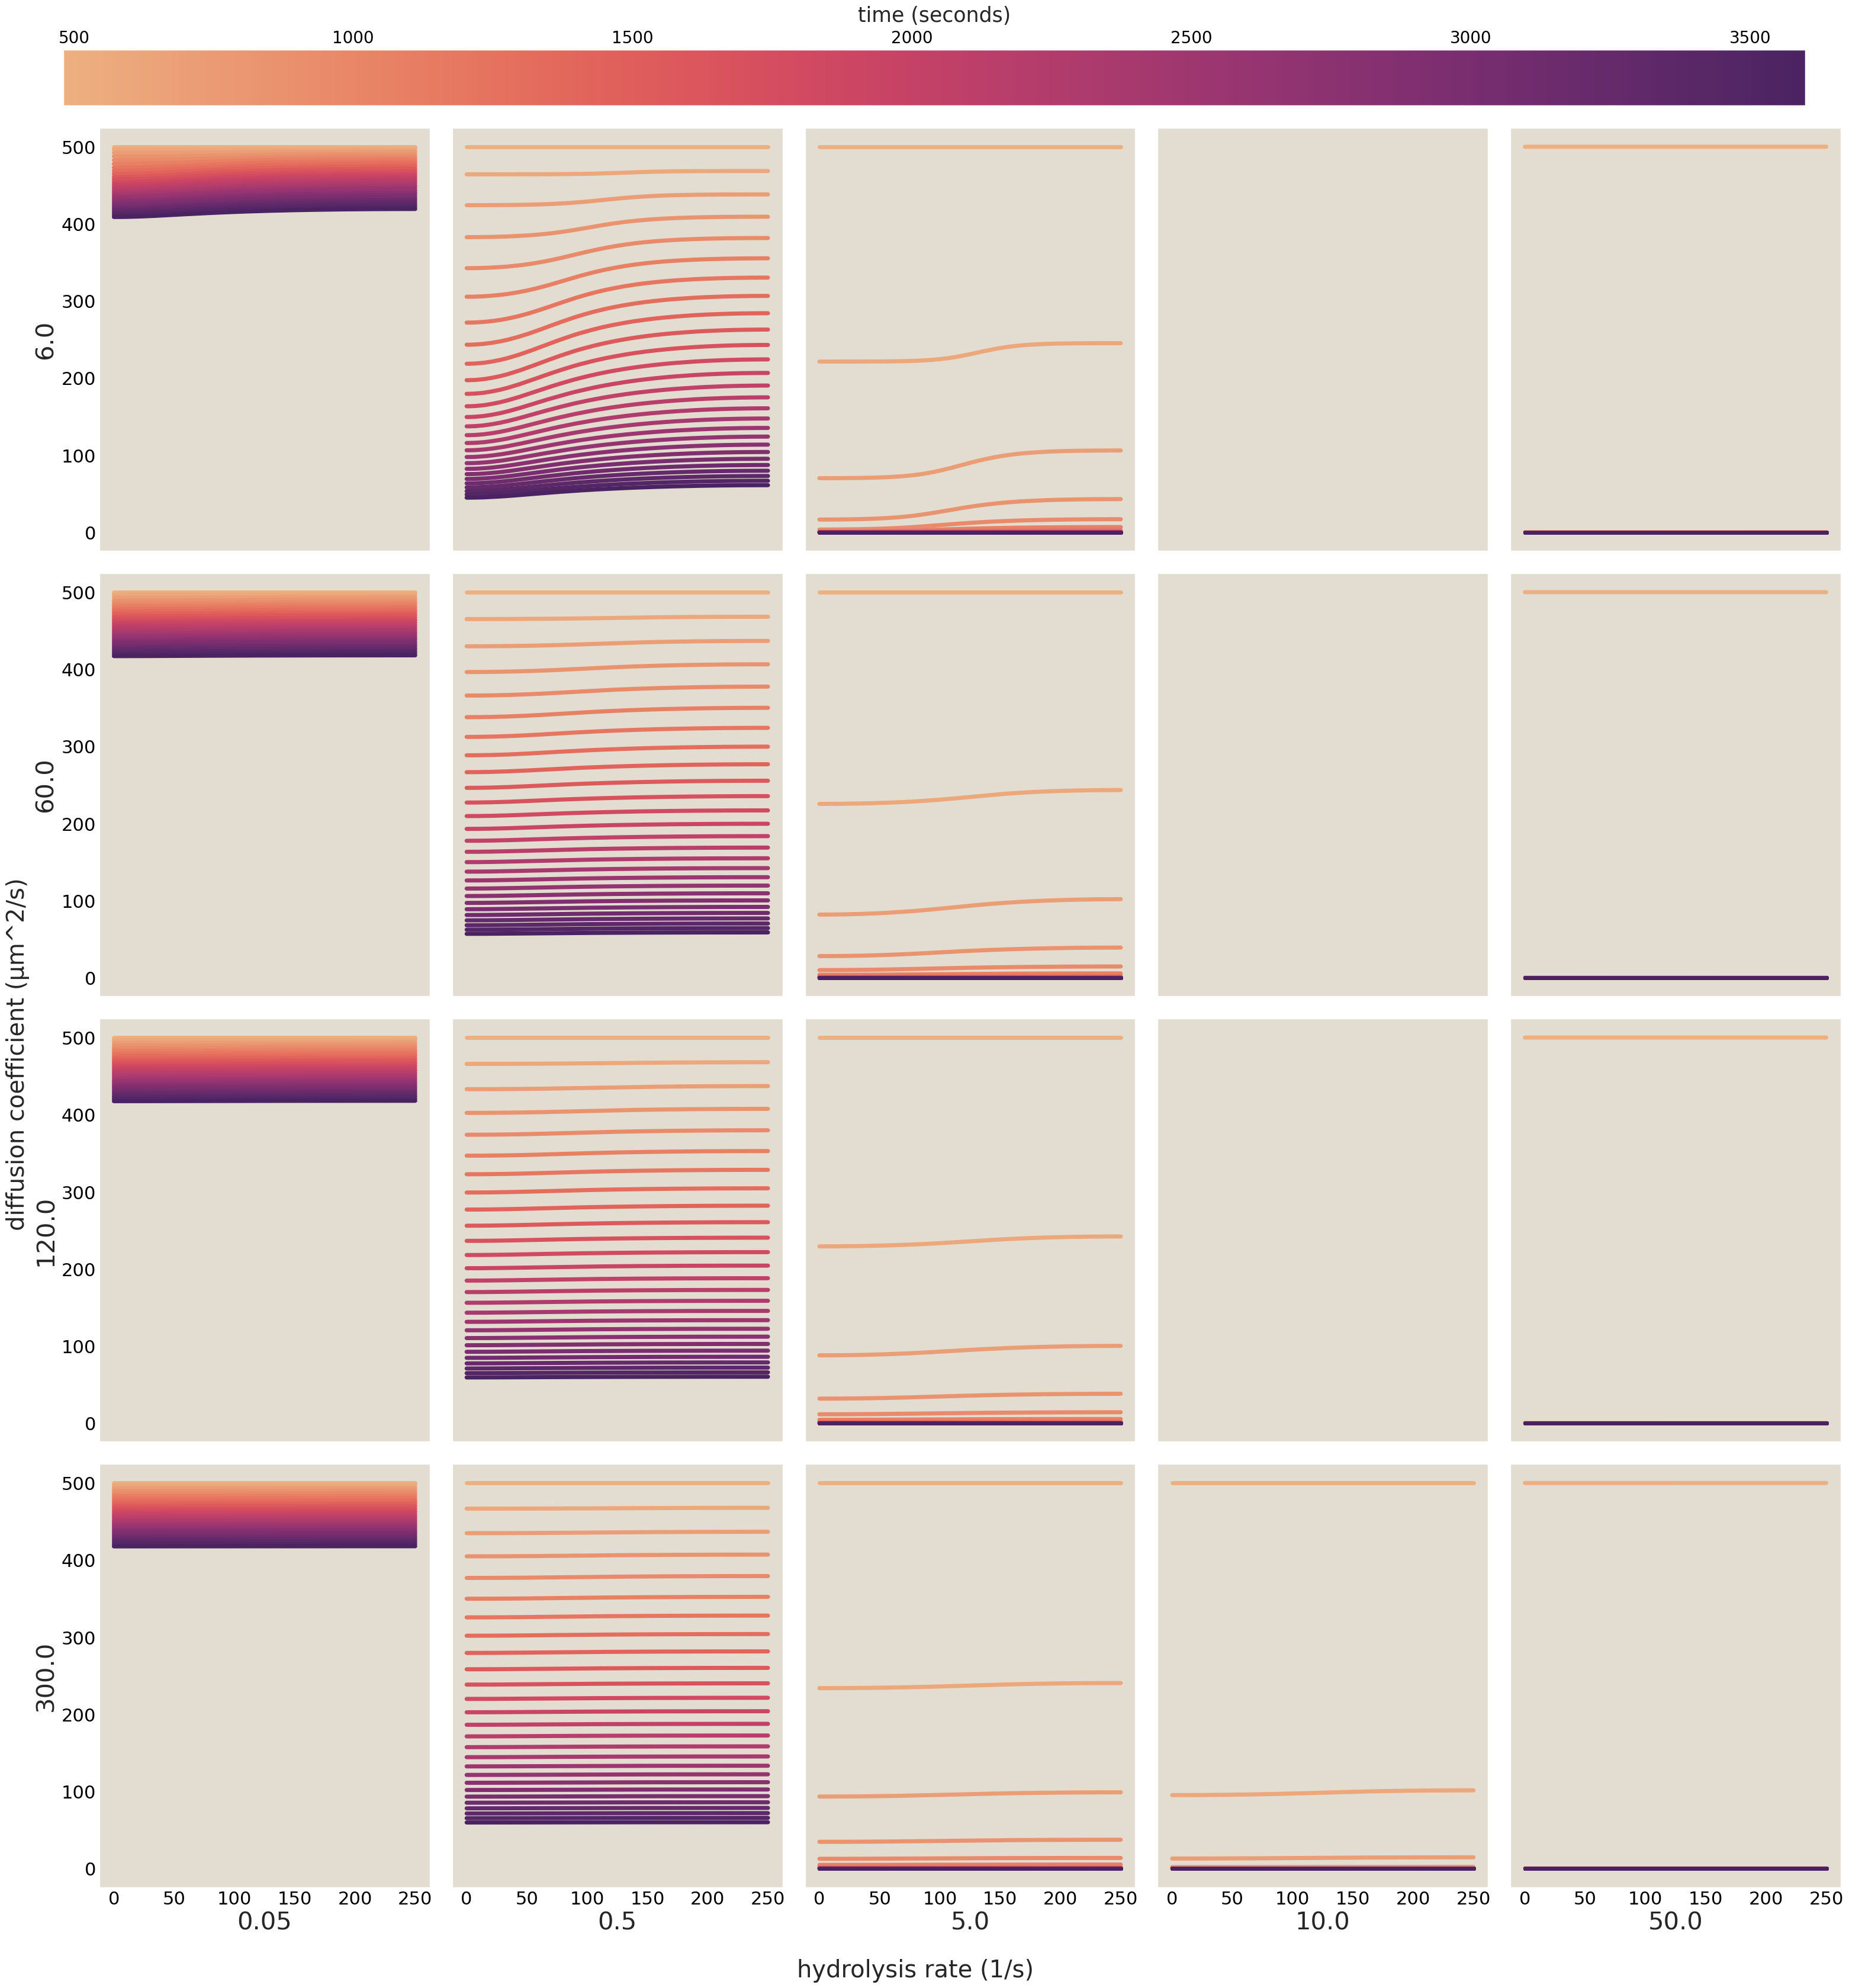

In [75]:
global_time=lambda time:sns.color_palette("flare", as_cmap=True)(matplotlib.colors.Normalize(vmin=comsol_df['time (s)'].min(), vmax=comsol_df['time (s)'].max())(time))

fig, ax = plt.subplots(len(np.unique(comsol_df['D (µM2/s)'])), 
                       len(np.unique(comsol_df['gamma (/s)'])), 
                       sharex=True, 
                       sharey=True,
                       figsize=(32,32))
for d, D in enumerate(np.sort(np.unique(comsol_df['D (µM2/s)']))):
    for g, G in enumerate(np.sort(np.unique(comsol_df['gamma (/s)']))):
        subsetdf=comsol_df[(comsol_df['D (µM2/s)']==D) & (comsol_df['gamma (/s)']==G)]

        for t, time in enumerate(np.unique(subsetdf['time (s)'])):
            ax[d][g].plot(subsetdf[subsetdf['time (s)']==time]['position (µm)'],
                       subsetdf[subsetdf['time (s)']==time]['ATP (µM)'],
                       color=global_time(time),
                       lw=5
                      )
            ax[-1][g].set_xlabel(G, fontsize=30)
            ax[d][0].set_ylabel(D, fontsize=30)


fig.supylabel('diffusion coefficient (µm^2/s)')
fig.supxlabel('hydrolysis rate (1/s)')

# Adjust the top margin to make space for the colorbar
fig.subplots_adjust(top=0.85)
#fig.subplots_adjust(right=0.85)

# Create an axis for the colorbar that spans all columns
cax = fig.add_axes([0.05, 1, 0.92, 0.03])  # horizontal [left, bottom, width, height]
#cax = fig.add_axes([1, 0.05, 0.03, 0.91])  # vertical [left, bottom, width, height]

# Create an axis for the colorbar that spans all columns
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=t_start, vmax=t_end)),cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=20)

# Move colorbar label and ticks to the top
cbar.ax.xaxis.set_ticks_position('top')   # Move ticks to top
cbar.ax.xaxis.set_label_position('top')   # Move label to top
cbar.set_label('time (seconds)', fontsize=25, labelpad=10)

plt.tight_layout()

# January 2026 Sweeps

We now made the chamber bigger (a 3mm x 3mm x 100um chamber with extra fine mesh in a circle of i think 300um which bleeds into a normal mesh for the rest of the chamber)

In [8]:
molperm3_to_uM = 1e3
mtoum = 1e6

comsol_file_path = '../../data/COMSOL/20260114_ATP_Depletion_modelADPtoo_3D_eqn-input-sigmoid/csvSweeps/'
comsol_file_globtag = '*atpProj*'
comsol_file_type = '.txt'
comment = '%'

In [9]:
glob.glob(comsol_file_path + comsol_file_globtag + comsol_file_type)

['../../data/COMSOL/20260114_ATP_Depletion_modelADPtoo_3D_eqn-input-sigmoid/csvSweeps/xzproj_D120gamma5_timedepmot_480-120-3600_atpProj.txt',
 '../../data/COMSOL/20260114_ATP_Depletion_modelADPtoo_3D_eqn-input-sigmoid/csvSweeps/xzproj_D300gamma0pt05_timedepmot_480-120-3600_atpProj.txt',
 '../../data/COMSOL/20260114_ATP_Depletion_modelADPtoo_3D_eqn-input-sigmoid/csvSweeps/xzproj_D120gamma0pt05_timedepmot_480-120-3600_atpProj.txt',
 '../../data/COMSOL/20260114_ATP_Depletion_modelADPtoo_3D_eqn-input-sigmoid/csvSweeps/xzproj_D60gamma0pt05_timedepmot_480-120-3600_atpProj.txt',
 '../../data/COMSOL/20260114_ATP_Depletion_modelADPtoo_3D_eqn-input-sigmoid/csvSweeps/xzproj_D60gamma0pt5_timedepmot_480-120-3600_atpProj.txt',
 '../../data/COMSOL/20260114_ATP_Depletion_modelADPtoo_3D_eqn-input-sigmoid/csvSweeps/xzproj_D6gamma0pt5_timedepmot_480-120-3600_atpProj.txt',
 '../../data/COMSOL/20260114_ATP_Depletion_modelADPtoo_3D_eqn-input-sigmoid/csvSweeps/xzproj_D6gamma5_timedepmot_480-120-3600_atpProj.

In [10]:
pd.read_csv('../../data/COMSOL/20250315_ATP_Depletion_3D_eqn-input-sigmoid/20251211_parameterSweep/csvs/xzproj_D60gamma0pt05_timedepmot_480-120-3600_atpProj.csv',comment=comment, names=["position (µm)", "ATP (µM)"])

,position (µm),ATP (µM)
0,0.000000,0.500000
1,0.000002,0.500000
2,0.000005,0.500000
3,0.000006,0.500000
4,0.000007,0.500000
...,...,...
4801,0.000244,0.417898
4802,0.000248,0.417898
4803,0.000249,0.417898
4804,0.000249,0.417898


In [11]:
globbedfiles = glob.glob(comsol_file_path + comsol_file_globtag + comsol_file_type)
fname = globbedfiles[1].split('/')[-1]
timeinfo = fname.split("_atp")[0].split('_')[-1]
gamma = fname.split('gamma')[1].split('_')[0]
gamma=gamma.replace('pt','.')
float(gamma)

0.05

In [15]:
comsol_df = pd.DataFrame(columns=["position (µm)", "ATP (µM)", 'time (s)', "D (µM2/s)", "gamma (/s)"])

globbedfiles = glob.glob(comsol_file_path + comsol_file_globtag + comsol_file_type)
for f, file in enumerate(globbedfiles):
    temp_df = pd.read_csv(file, comment=comment, names=["position (µm)", "ATP (µM)"])
    temp_df['position (µm)'] = temp_df['position (µm)']*mtoum
    temp_df['ATP (µM)'] = temp_df['ATP (µM)']*molperm3_to_uM

    fname = file.split('/')[-1]

    #make the time array
    timeinfo = fname.split("_atp")[0].split('_')[-1]
    t_start = 0#int(timeinfo.split('-')[0]) #initial time
    t_end = int(timeinfo.split('-')[-1]) # final time
    spacing = int(timeinfo.split('-')[1]) # seconds between each measurement
    interval = 1 #plotting interval
    
    comsol_time_ls = comsolTimeGenerator(t_start, t_end, spacing, interval, temp_df['position (µm)'])
    temp_df['time (s)']= comsol_time_ls
    
    temp_df['D (µM2/s)'] = float(fname.split('D')[-1].split('gamma')[0])
    
    gamma = fname.split('gamma')[1].split('_')[0]
    if 'pt' in gamma:
        gamma=gamma.replace('pt','.')
    temp_df['gamma (/s)'] = float(gamma)

    
    comsol_df=pd.concat([comsol_df, temp_df])

        


In [16]:
comsol_df

,position (µm),ATP (µM),time (s),D (µM2/s),gamma (/s)
0,0.000000,499.980058,0.0,120.0,5.0
1,6.383444,499.980058,0.0,120.0,5.0
2,6.530768,499.980058,0.0,120.0,5.0
3,6.627209,499.980058,0.0,120.0,5.0
4,14.507529,499.980058,0.0,120.0,5.0
...,...,...,...,...,...
6071,1442.264973,46.058630,3600.0,300.0,0.5
6072,1461.509982,46.058776,3600.0,300.0,0.5
6073,1471.132487,46.058848,3600.0,300.0,0.5
6074,1476.889866,46.058892,3600.0,300.0,0.5


/var/folders/8p/dg75nl0d7ml8f_vqy6lvm3740000gn/T/ipykernel_51866/2812341948.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


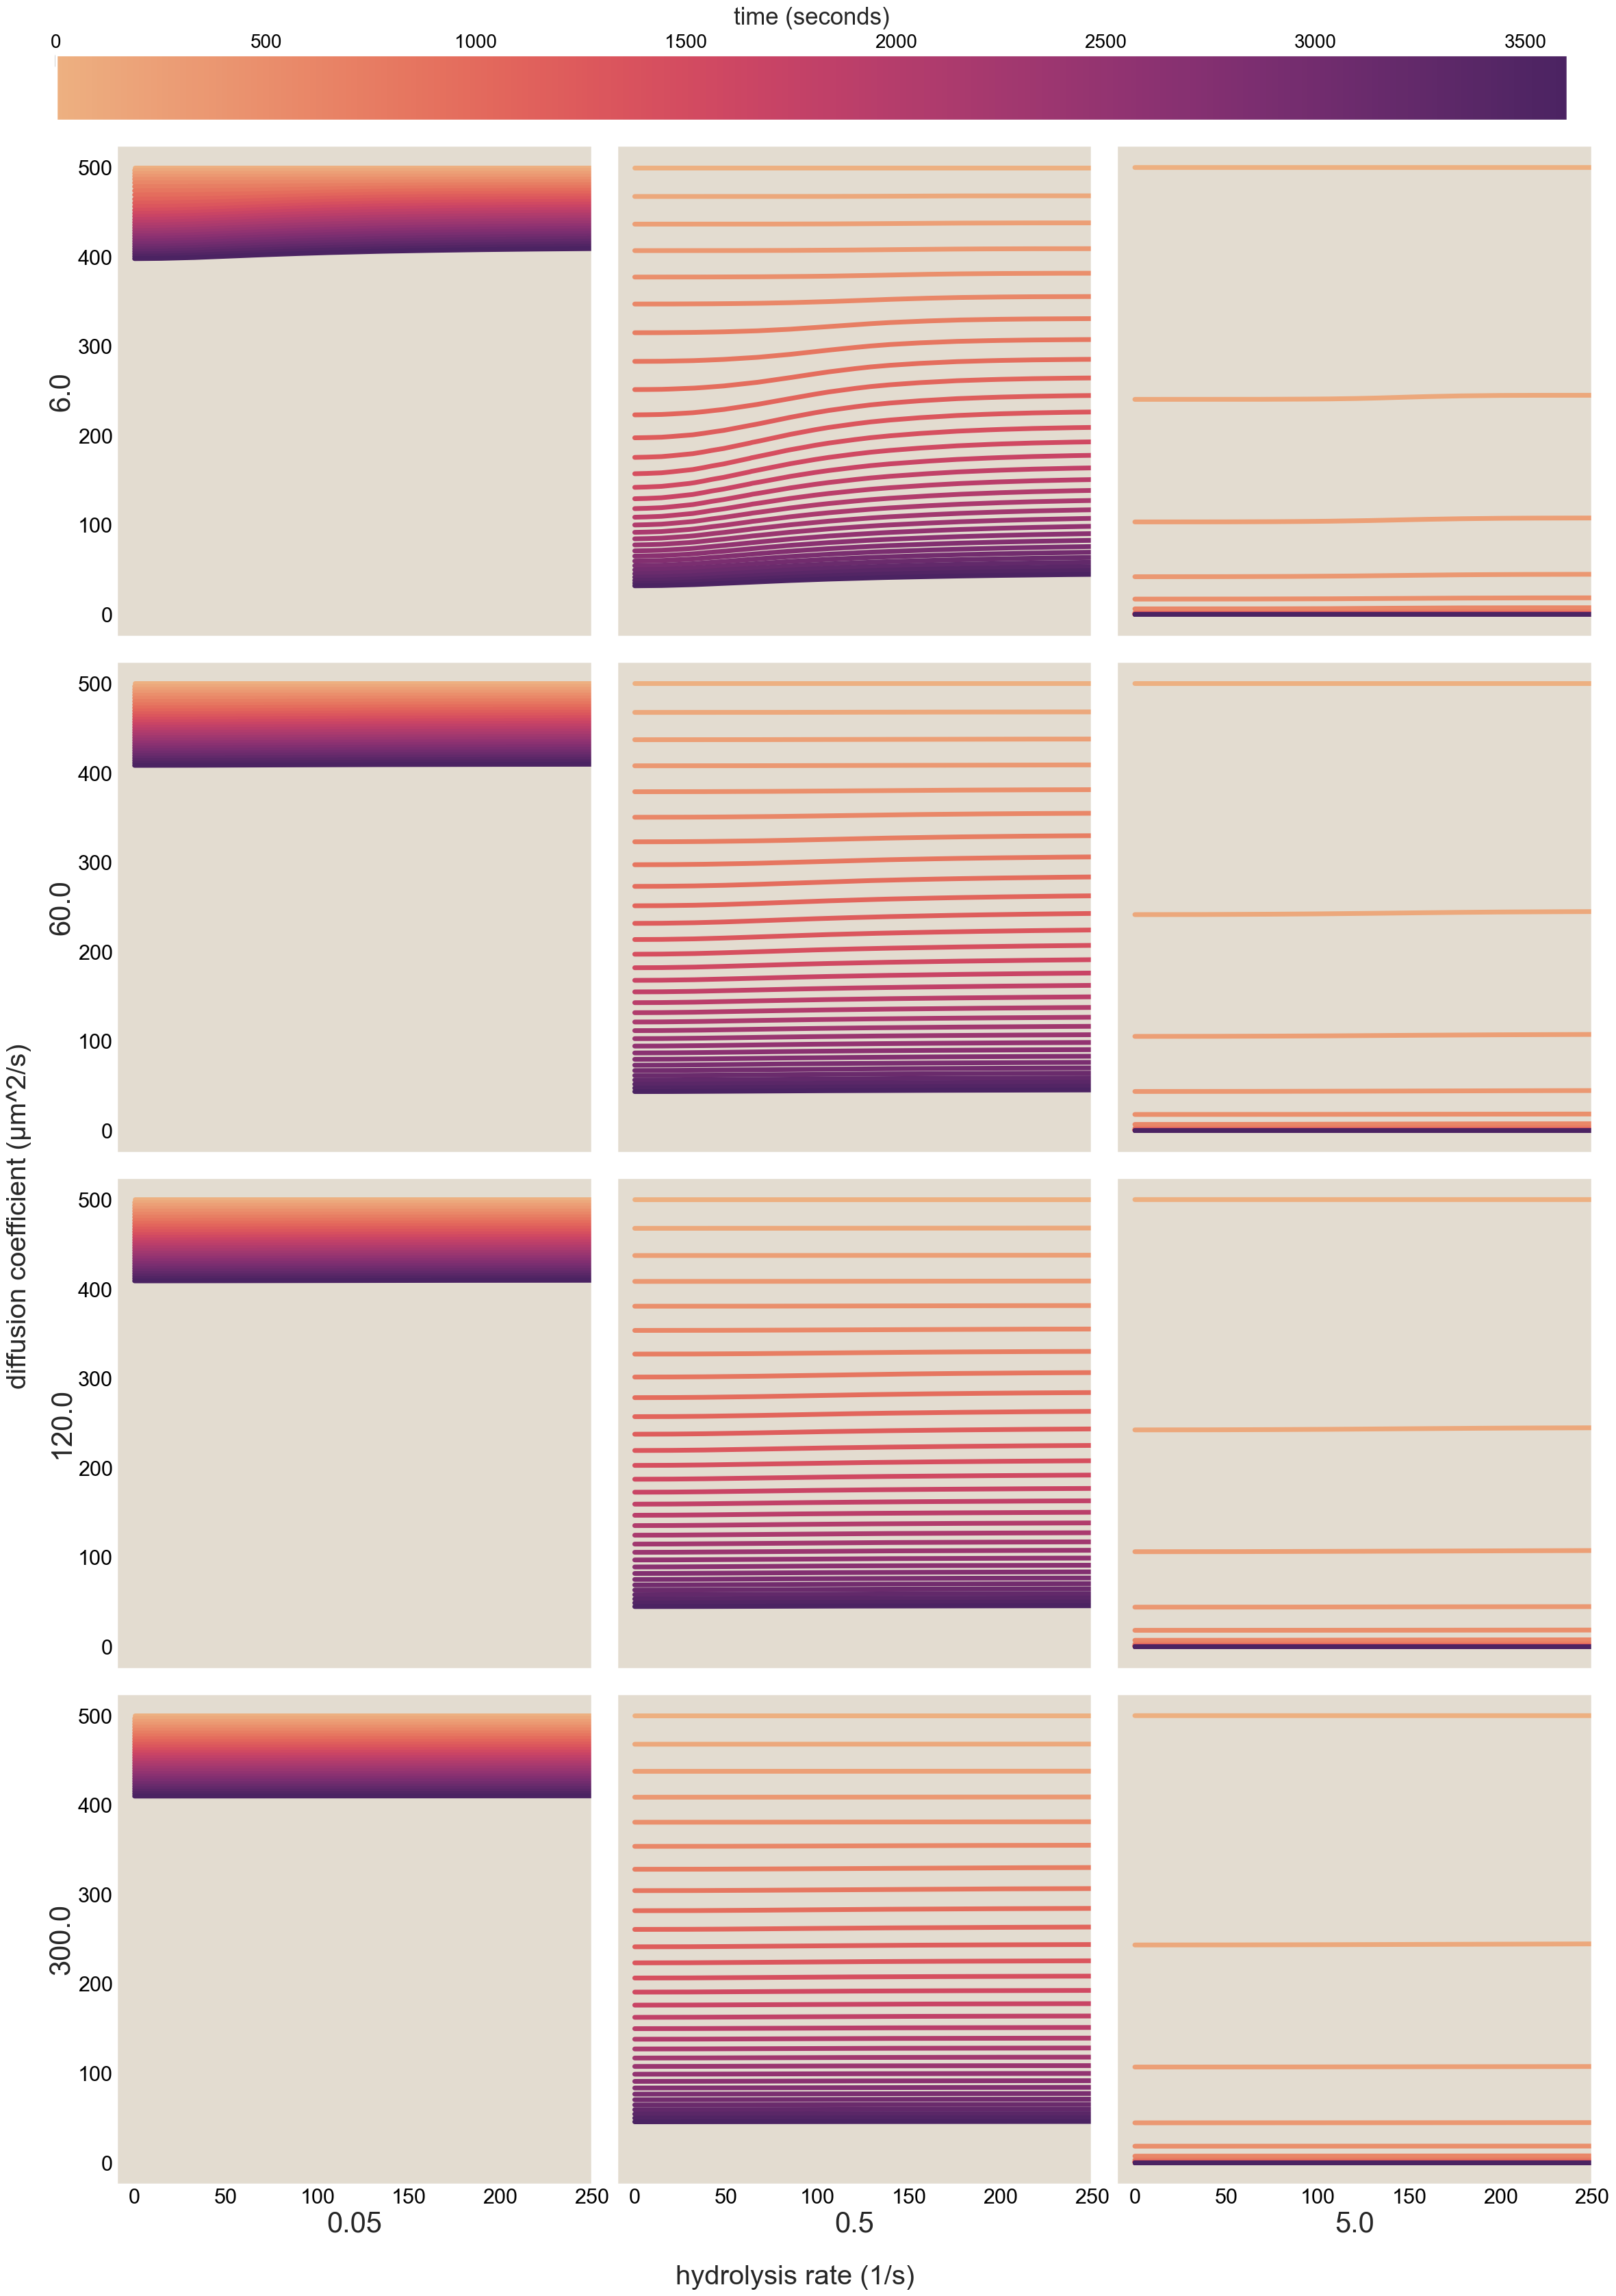

In [21]:
global_time=lambda time:sns.color_palette("flare", as_cmap=True)(matplotlib.colors.Normalize(vmin=comsol_df['time (s)'].min(), vmax=comsol_df['time (s)'].max())(time))

fig, ax = plt.subplots(len(np.unique(comsol_df['D (µM2/s)'])), 
                       len(np.unique(comsol_df['gamma (/s)'])), 
                       sharex=True, 
                       sharey=True,
                       figsize=(24,32))
for d, D in enumerate(np.sort(np.unique(comsol_df['D (µM2/s)']))):
    for g, G in enumerate(np.sort(np.unique(comsol_df['gamma (/s)']))):
        subsetdf=comsol_df[(comsol_df['D (µM2/s)']==D) & (comsol_df['gamma (/s)']==G)]

        for t, time in enumerate(np.unique(subsetdf['time (s)'])):
            ax[d][g].plot(subsetdf[subsetdf['time (s)']==time]['position (µm)'],
                       subsetdf[subsetdf['time (s)']==time]['ATP (µM)'],
                       color=global_time(time),
                       lw=5
                      )
            ax[-1][g].set_xlabel(G, fontsize=30)
            ax[d][0].set_ylabel(D, fontsize=30)

ax[0][0].set_xlim(-10, 250)
fig.supylabel('diffusion coefficient (µm^2/s)')
fig.supxlabel('hydrolysis rate (1/s)')

# Adjust the top margin to make space for the colorbar
fig.subplots_adjust(top=0.85)
#fig.subplots_adjust(right=0.85)

# Create an axis for the colorbar that spans all columns
cax = fig.add_axes([0.05, 1, 0.92, 0.03])  # horizontal [left, bottom, width, height]
#cax = fig.add_axes([1, 0.05, 0.03, 0.91])  # vertical [left, bottom, width, height]

# Create an axis for the colorbar that spans all columns
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=t_start, vmax=t_end)),cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=20)

# Move colorbar label and ticks to the top
cbar.ax.xaxis.set_ticks_position('top')   # Move ticks to top
cbar.ax.xaxis.set_label_position('top')   # Move label to top
cbar.set_label('time (seconds)', fontsize=25, labelpad=10)

plt.tight_layout()

/var/folders/8p/dg75nl0d7ml8f_vqy6lvm3740000gn/T/ipykernel_51866/1400688190.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


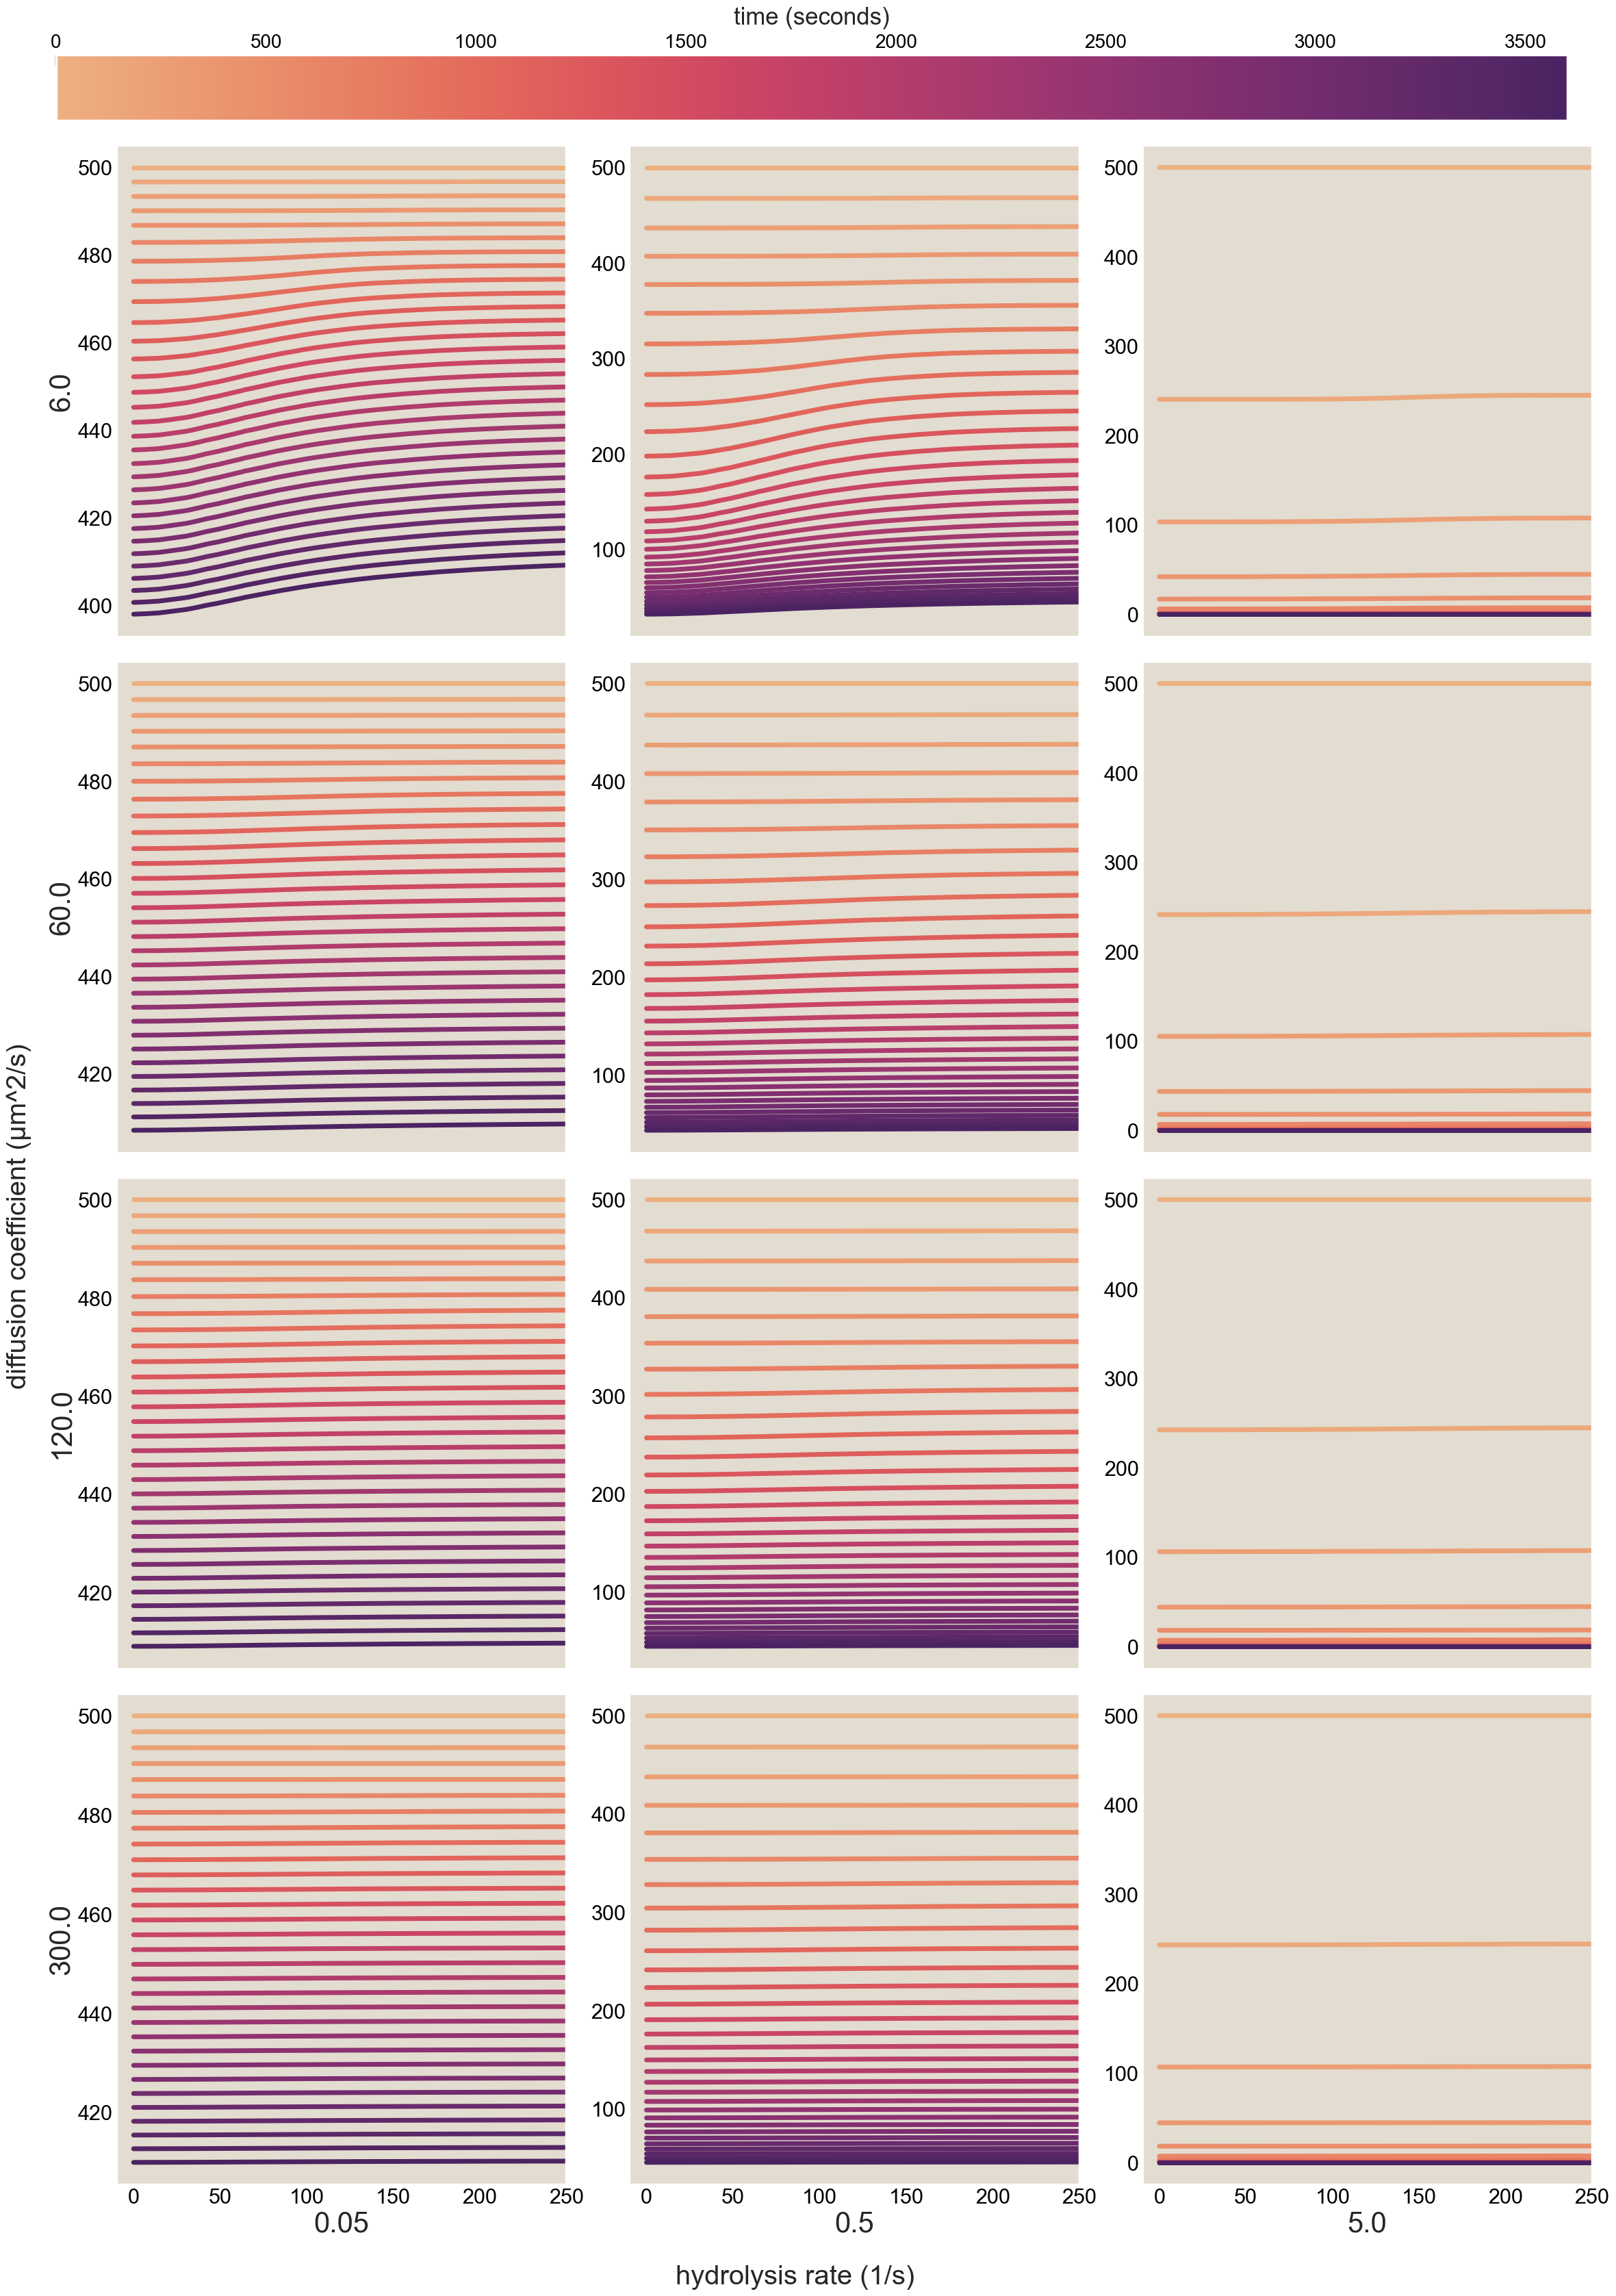

In [27]:
global_time=lambda time:sns.color_palette("flare", as_cmap=True)(matplotlib.colors.Normalize(vmin=comsol_df['time (s)'].min(), vmax=comsol_df['time (s)'].max())(time))

fig, ax = plt.subplots(len(np.unique(comsol_df['D (µM2/s)'])), 
                       len(np.unique(comsol_df['gamma (/s)'])), 
                       sharex=True,
                       figsize=(24,32))
for d, D in enumerate(np.sort(np.unique(comsol_df['D (µM2/s)']))):
    for g, G in enumerate(np.sort(np.unique(comsol_df['gamma (/s)']))):
        subsetdf=comsol_df[(comsol_df['D (µM2/s)']==D) & (comsol_df['gamma (/s)']==G)]

        for t, time in enumerate(np.unique(subsetdf['time (s)'])):
            ax[d][g].plot(subsetdf[subsetdf['time (s)']==time]['position (µm)'],
                       subsetdf[subsetdf['time (s)']==time]['ATP (µM)'],
                       color=global_time(time),
                       lw=5
                      )
            ax[-1][g].set_xlabel(G, fontsize=30)
            ax[d][0].set_ylabel(D, fontsize=30)

ax[0][0].set_xlim(-10, 250)
fig.supylabel('diffusion coefficient (µm^2/s)')
fig.supxlabel('hydrolysis rate (1/s)')

# Adjust the top margin to make space for the colorbar
fig.subplots_adjust(top=0.85)
#fig.subplots_adjust(right=0.85)

# Create an axis for the colorbar that spans all columns
cax = fig.add_axes([0.05, 1, 0.92, 0.03])  # horizontal [left, bottom, width, height]
#cax = fig.add_axes([1, 0.05, 0.03, 0.91])  # vertical [left, bottom, width, height]

# Create an axis for the colorbar that spans all columns
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=t_start, vmax=t_end)),cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=20)

# Move colorbar label and ticks to the top
cbar.ax.xaxis.set_ticks_position('top')   # Move ticks to top
cbar.ax.xaxis.set_label_position('top')   # Move label to top
cbar.set_label('time (seconds)', fontsize=25, labelpad=10)

plt.tight_layout()